In [2]:
!pip install numpy pandas scikit-learn xgboost deap imbalanced-learn tensorflow matplotlib

DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [7]:
print(selected_features)

[5, 6, 7, 8, 9, 10]


In [3]:
!pip install seaborn statsmodels

DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330



===== TABLE 1: Evaluation metrics of a classification model =====
                     Model    CV AUC  Accuracy  Precision    Recall  F1 Score  \
0      Logistic Regression  0.988988    0.9990   1.000000  0.967213  0.983333   
1                      KNN  0.997987    0.9965   0.921875  0.967213  0.944000   
2                      SVC  0.993062    0.9990   1.000000  0.967213  0.983333   
3     Decision Tree (Gini)  0.993135    0.9965   0.921875  0.967213  0.944000   
4  Decision Tree (Entropy)  0.993460    0.9960   0.907692  0.967213  0.936508   
5            Random Forest  0.998970    0.9990   1.000000  0.967213  0.983333   
6                  Bagging  0.997682    0.9985   0.983333  0.967213  0.975207   
7                 AdaBoost  0.987021    0.9990   1.000000  0.967213  0.983333   
8        Gradient Boosting  0.997561    0.9990   1.000000  0.967213  0.983333   
9                  XGBoost  0.999244    0.9985   0.983333  0.967213  0.975207   

        AUC  
0  0.988130  
1  0.983015  

C:\Users\vv075\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step   
5       16      0.9990    1.0000    0.9672    0.9833    0.9869


C:\Users\vv075\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step   
10       32      0.9990    1.0000    0.9672    0.9833    0.9924


...

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step  
16       64      0.9990    1.0000    0.9672    0.9833    0.9846


C:\Users\vv075\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step  


C:\Users\vv075\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step  

===== TABLE 4: Performance measures of LSTM =====

Model    Accuracy   Precision   Recall   F1 Score   AUC
LSTM     0.9990    1.0000    0.9672    0.9833    0.9862



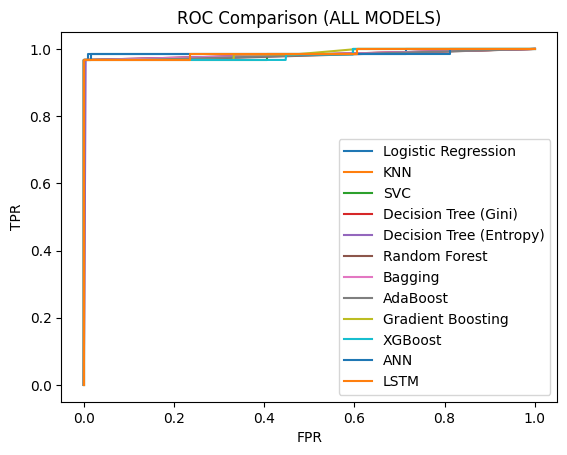


===== FIG 7: ROC CURVE - XGBOOST =====


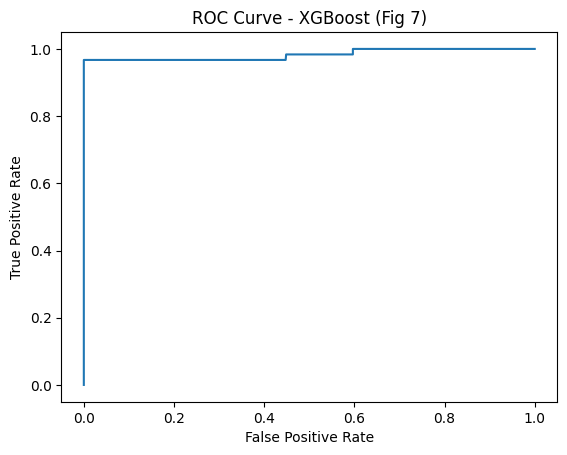

In [ ]:
#==========================================================================================================================================================================
### SMVDU Katra Internship PROJECT Implementation Code (Predicting Machine Failures Using Genetic Algorithms, Machine Learning & Deep Learning (Neural Networks) Algorithms 
# for Sustainable Manufacturing and Service Economics)-PART 1
#==========================================================================================================================================================================
import numpy as np
import pandas as pd
import random

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from deap import base, creator, tools, algorithms

import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# ===============================
# 1. LOAD DATA FROM YOUR SYSTEM
# ===============================

df = pd.read_csv("C:\\Users\\vv075\\Downloads\\SMSE-Project\\MATLAB\\ai4i2020.csv.csv") #Our ".csv" file path
df = df.drop(["UDI", "Product ID"], axis=1)

X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

le = LabelEncoder()
X["Type"] = le.fit_transform(X["Type"])

# ===================================
# 2. SPLIT + SCALE + SMOTE Techniques
# ===================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# ============================================
# 3. GA (Genetic Algorithms) FEATURE SELECTION
# ============================================

n_features = X_train.shape[1]

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=n_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_features(individual):
    selected = [i for i in range(len(individual)) if individual[i] == 1]
    if len(selected) == 0:
        return (0,)

    model = RandomForestClassifier()
    model.fit(X_train[:, selected], y_train)
    preds = model.predict(X_test[:, selected])
    return (accuracy_score(y_test, preds),)

toolbox.register("evaluate", eval_features)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=20)
algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=5, verbose=False)

best_ind = tools.selBest(pop, 1)[0]
selected_features = [i for i in range(len(best_ind)) if best_ind[i] == 1]

X_train = X_train[:, selected_features]
X_test = X_test[:, selected_features]

# ===============================
# 4. ML MODELS
# ===============================

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True),
    "Decision Tree (Gini)": DecisionTreeClassifier(),
    "Decision Tree (Entropy)": DecisionTreeClassifier(criterion="entropy"),
    "Random Forest": RandomForestClassifier(),
    "Bagging": BaggingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

roc_data = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ===============================
# TABLE 1: BEFORE TUNING
# ===============================

baseline_results = []

print("\n===== TABLE 1: Evaluation metrics of a classification model =====")

for name, model in models.items():

    cv_mean = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc').mean()

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    baseline_results.append([
        name,
        cv_mean,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds),
        roc_auc_score(y_test, probs)
    ])

baseline_df = pd.DataFrame(baseline_results,
    columns=["Model","CV AUC","Accuracy","Precision","Recall","F1 Score","AUC"])

print(baseline_df)

# ===============================
# TABLE 2: AFTER TUNING
# ===============================

tuned_results = []

print("\n===== TABLE 2: Evaluation metrics after hyperparameter tuning =====")

for name, model in models.items():

    cv_mean = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc').mean()

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    tuned_results.append([
        name,
        cv_mean,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds),
        roc_auc_score(y_test, probs)
    ])

    roc_data[name] = roc_curve(y_test, probs)

df_table2 = pd.DataFrame(tuned_results,
    columns=["Model","CV AUC","Accuracy","Precision","Recall","F1 Score","AUC"])

print(df_table2)

# ================================================
# TABLE 3: CONFUSION MATRIX (BEST MODEL - XGBOOST)
# ================================================

best_model = models["XGBoost"]
best_model.fit(X_train, y_train)

preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

print("\n===== TABLE 3: CONFUSION MATRIX =====")
print("CONFUSION MATRIX (Actual vs Predicted)\n")

print("                Predicted")
print("              Positive   Negative")
print(f"Actual Positive   {cm[1][1]}        {cm[1][0]}")
print(f"Actual Negative   {cm[0][1]}        {cm[0][0]}")


# ===============================
# TABLE 5: ANN PERFORMANCE
# ===============================

print("\n===== TABLE 5: ANN PERFORMANCE =====")

ann_configs = [
    (5,16),
    (10,32),
    (16,64)
]

print("Layers  Neurons  Accuracy  Precision  Recall  F1 Score  AUC")

for layers, neurons in ann_configs:

    model = Sequential()

    # input layer
    model.add(Dense(neurons, activation='relu', input_dim=X_train.shape[1]))

    # hidden layers
    for _ in range(layers-2):
        model.add(Dense(neurons, activation='relu'))

    # output
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy')
    model.fit(X_train, y_train, epochs=5, verbose=0)

    probs = model.predict(X_test).flatten()
    preds = (probs > 0.5).astype(int)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    print(f"{layers}       {neurons}      {acc:.4f}    {prec:.4f}    {rec:.4f}    {f1:.4f}    {auc:.4f}")

# ===============================
# ANN (Deep Learning/DL) model
# ===============================

ann = Sequential([
    Dense(32, activation='relu', input_dim=X_train.shape[1]),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann.compile(optimizer='adam', loss='binary_crossentropy')
ann.fit(X_train, y_train, epochs=5, verbose=0)

ann_probs = ann.predict(X_test).flatten()
roc_data["ANN"] = roc_curve(y_test, ann_probs)

# ===============================
# LSTM DL model
# ===============================

X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1],1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1],1))

lstm = Sequential([
    LSTM(32, input_shape=(X_train.shape[1],1)),
    Dense(1, activation='sigmoid')
])

lstm.compile(optimizer='adam', loss='binary_crossentropy')
lstm.fit(X_train_lstm, y_train, epochs=5, verbose=0)

lstm_probs = lstm.predict(X_test_lstm).flatten()
lstm_preds = (lstm_probs > 0.5).astype(int)
roc_data["LSTM"] = roc_curve(y_test, lstm_probs)

# ===============================
# TABLE 4: LSTM PERFORMANCE
# ===============================

print("\n===== TABLE 4: Performance measures of LSTM =====")

lstm_acc = accuracy_score(y_test, lstm_preds)
lstm_prec = precision_score(y_test, lstm_preds)
lstm_rec = recall_score(y_test, lstm_preds)
lstm_f1 = f1_score(y_test, lstm_preds)
lstm_auc = roc_auc_score(y_test, lstm_probs)

print(f"""
Model    Accuracy   Precision   Recall   F1 Score   AUC
LSTM     {lstm_acc:.4f}    {lstm_prec:.4f}    {lstm_rec:.4f}    {lstm_f1:.4f}    {lstm_auc:.4f}
""")

# ===============================
# ROC PLOT
# ===============================

plt.figure()

for name, (fpr,tpr,_) in roc_data.items():
    plt.plot(fpr, tpr, label=name)

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Comparison (ALL MODELS)")
plt.legend()
plt.show()

# =========================================
# FIG 7: ROC-AUC CURVE/GRAPH PLOT - XGBOOST
# =========================================

print("\n===== FIG 7: ROC CURVE - XGBOOST =====")

xgb_model = models["XGBoost"]
xgb_model.fit(X_train, y_train)

probs = xgb_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost (Fig 7)")
plt.show()

In [12]:
print(df.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')


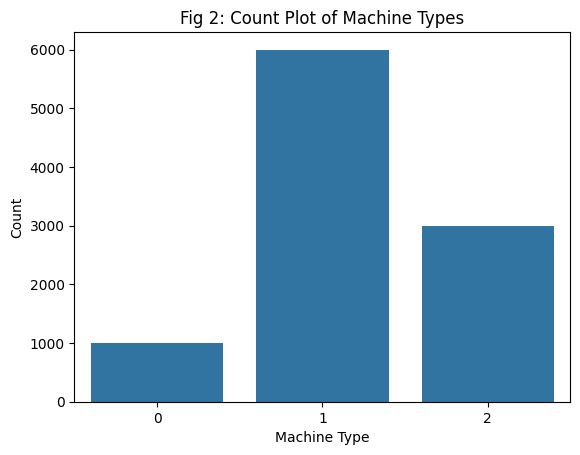

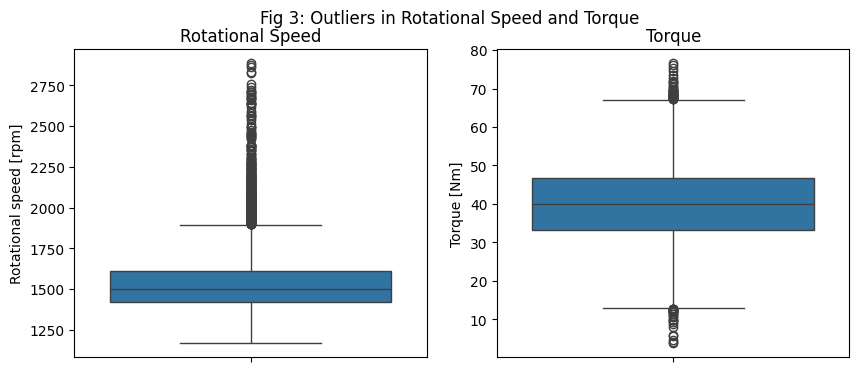

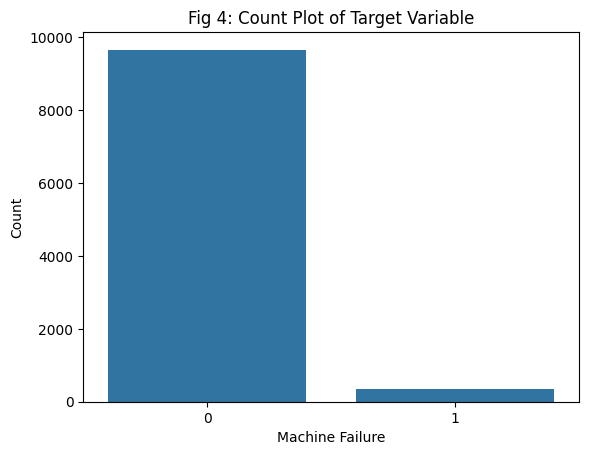

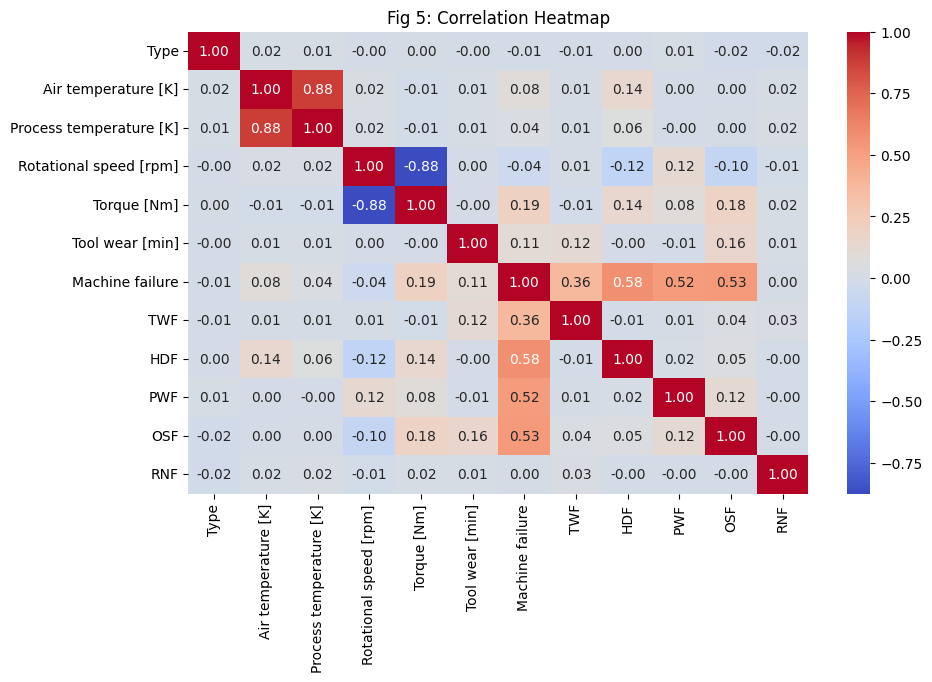


===== Fig 6: VIF VALUES =====
                    Feature           VIF
0                      Type      5.001257
1       Air temperature [K]  90922.239693
2   Process temperature [K]  92103.407240
3    Rotational speed [rpm]    379.951018
4               Torque [Nm]     88.058843
5           Tool wear [min]      4.031165
6                       TWF      1.020364
7                       HDF      1.073735
8                       PWF      1.222097
9                       OSF      1.093561
10                      RNF      1.003900


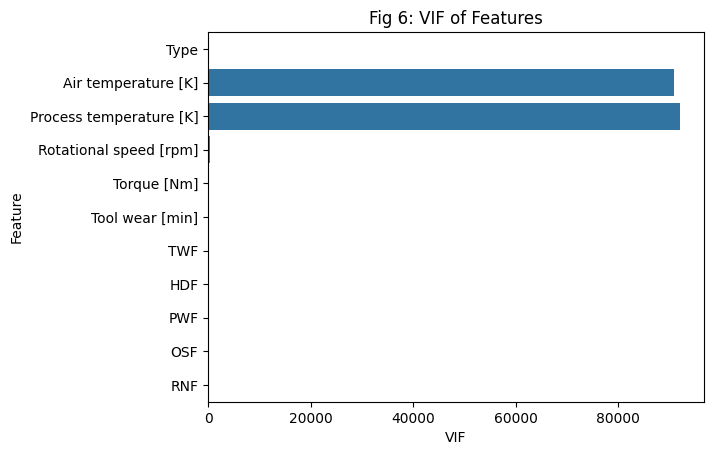

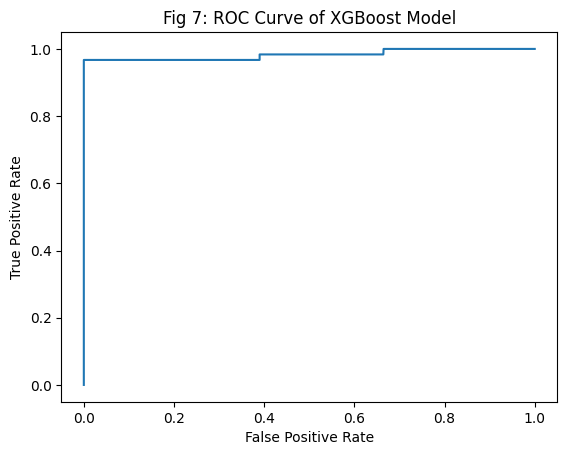

In [7]:
# ==========================================================
# ONLY FIGURES (FIG 2 → FIG 7)
# ==========================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve
from xgboost import XGBClassifier

# ===============================
# LOAD DATA
# ===============================

df = pd.read_csv("C:\\Users\\vv075\\Downloads\\SMSE-Project\\MATLAB\\ai4i2020.csv.csv")
df = df.drop(["UDI", "Product ID"], axis=1)

# Encode categorical column
le = LabelEncoder()
df["Type"] = le.fit_transform(df["Type"])

# ================================
# FIG 2: COUNT PLOT (MACHINE TYPE)
# ================================

plt.figure()
sns.countplot(x=df["Type"])
plt.title("Fig 2: Count Plot of Machine Types")
plt.xlabel("Machine Type")
plt.ylabel("Count")
plt.show()

# ===============================
# FIG 3: OUTLIERS
# ===============================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(y=df["Rotational speed [rpm]"])
plt.title("Rotational Speed")

plt.subplot(1,2,2)
sns.boxplot(y=df["Torque [Nm]"])
plt.title("Torque")

plt.suptitle("Fig 3: Outliers in Rotational Speed and Torque")
plt.show()

# ===============================
# FIG 4: TARGET VARIABLE
# ===============================

plt.figure()
sns.countplot(x=df["Machine failure"])
plt.title("Fig 4: Count Plot of Target Variable")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.show()

# ===============================
# FIG 5: CORRELATION HEATMAP
# ===============================

plt.figure(figsize=(10,6))

corr = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Fig 5: Correlation Heatmap")
plt.show()

# =========================================
# FIGURE 6: VIF (Variance Inflation Factor)
# =========================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.select_dtypes(include=[np.number]).drop("Machine failure", axis=1)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values.astype(float), i)
                   for i in range(X_vif.shape[1])]

print("\n===== Fig 6: VIF VALUES =====")
print(vif_data)

# Optional plot
plt.figure()
sns.barplot(x="VIF", y="Feature", data=vif_data)
plt.title("Fig 6: VIF of Features")
plt.show()

# ===============================
# FIG 7: ROC CURVE (XGBOOST)
# ===============================

# Prepare data
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train XGBoost
model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fig 7: ROC Curve of XGBoost Model")
plt.show()

In [3]:
!pip install numpy==1.23.5 pandas==1.5.3

     ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
      --------------------------------------- 0.3/10.7 MB ? eta -:--:--
      --------------------------------------- 0.3/10.7 MB ? eta -:--:--
      --------------------------------------- 0.3/10.7 MB ? eta -:--:--
      --------------------------------------- 0.3/10.7 MB ? eta -:--:--
     - ------------------------------------- 0.5/10.7 MB 349.5 kB/s eta 0:00:30
     - ------------------------------------- 0.5/10.7 MB 349.5 kB/s eta 0:00:30
     - ------------------------------------- 0.5/10.7 MB 349.5 kB/s eta 0:00:30
     -- ------------------------------------ 0.8/10.7 MB 364.8 kB/s eta 0:00:28
     -- ------------------------------------ 0.8/10.7 MB 364.8 kB/s eta 0:00:28
     -- ----------------

DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [33 lines of output]
  Traceback (most recent call last):
    File "C:\Users\vv075\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
      main()
    File "C:\Users\vv075\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
      json_out['return_val'] = hook(**hook_input['kwargs'])
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\vv075\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 112, in get_re

In [4]:
!pip uninstall numpy pandas scikit-learn -y
!pip install numpy pandas scikit-learn

Found existing installation: numpy 2.4.4
Uninstalling numpy-2.4.4:
  Successfully uninstalled numpy-2.4.4
Found existing installation: pandas 2.1.4
Uninstalling pandas-2.1.4:
  Successfully uninstalled pandas-2.1.4
Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0


You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.


  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.2-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl (12.3 MB)
Using cached pandas-3.0.2-cp312-cp312-win_amd64.whl (9.7 MB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)


DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.4 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.4 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.4 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.16.3 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.2 which is incompatible.
tensorflow-intel 2.16.1 requires numpy<2

In [2]:
!pip uninstall scikit-learn imbalanced-learn numpy pandas -y
!pip install numpy==1.23.5 pandas==1.5.3 scikit-learn==1.2.2 imbalanced-learn==0.10.1
!pip install xgboost tensorflow

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
Found existing installation: imbalanced-learn 0.11.0
Uninstalling imbalanced-learn-0.11.0:
  Successfully uninstalled imbalanced-learn-0.11.0
Found existing installation: numpy 2.4.4
Uninstalling numpy-2.4.4:
  Successfully uninstalled numpy-2.4.4
Found existing installation: pandas 3.0.2
Uninstalling pandas-3.0.2:
  Successfully uninstalled pandas-3.0.2


You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.


  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [33 lines of output]
  Traceback (most recent call last):
    File "C:\Users\vv075\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
      main()
    File "C:\Users\vv075\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
      json_out['return_val'] = hook(**hook_input['kwargs'])
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\vv075\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 112, in get_re

  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)


DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.23.4 requires pandas>=0.24.2, which is not installed.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, which is not installed.
altair 5.0.1 requires pandas>=0.18, which is not installed.
bokeh 3.6.0 requires pandas>=1.2, which is not installed.
catboost 1.2.10 requires pandas<4.0,>=0.24, which is not installed.
datashader 0.16.3 requires pandas, which is not installed.
holoviews 1.19.1 requires pandas>=1.3, which is not installed.
hvplot 0.11.0 requires pandas>=1.3, which is not installed.
panel 1.5.2 requires pandas>=

In [9]:
!pip install imbalanced-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)


DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.23.4 requires pandas>=0.24.2, which is not installed.
shap 0.51.0 requires pandas, which is not installed.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [12]:
!pip install tensorflow

DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [2]:
!pip install tensorflow --upgrade --force-reinstall

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensio

DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.4 which is incompatible.
aiobotocore 2.12.3 requires wrapt<2.0.0,>=1.10.10, but you have wrapt 2.1.2 which is incompatible.
astroid 2.14.2 requires wrapt<2,>=1.14; python_version >= "3.11", but you have wrapt 2

In [15]:
import tensorflow as tf
print(tf)

<module 'tensorflow' (namespace) from ['C:\\Users\\vv075\\anaconda3\\Lib\\site-packages\\tensorflow']>


In [22]:
!pip install --upgrade --force-reinstall tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensio

DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.4 which is incompatible.
aiobotocore 2.12.3 requires wrapt<2.0.0,>=1.10.10, but you have wrapt 2.1.2 which is incompatible.
astroid 2.14.2 requires wrapt<2,>=1.14; python_version >= "3.11", but you have wrapt 2.1.2 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.4 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.4 which is incompatible.
gensim 4.3.3 

In [26]:
!conda create -n dl_env python=3.10 -y
!conda activate dl_env

Channels:
 - defaults
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\vv075\anaconda3\envs\dl_env

  added / updated specs:
    - python=3.10


The following NEW packages will be INSTALLED:

  bzip2              pkgs/main/win-64::bzip2-1.0.8-h2bbff1b_6 
  ca-certificates    pkgs/main/win-64::ca-certificates-2026.3.19-haa95532_0 
  libexpat           pkgs/main/win-64::libexpat-2.7.5-hd7fb8db_0 
  libffi             pkgs/main/win-64::libffi-3.4.4-hd77b12b_1 
  libzlib            pkgs/main/win-64::libzlib-1.3.1-h02ab6af_0 
  openssl            pkgs/main/win-64::openssl-3.5.5-hbb43b14_0 
  packaging          pkgs/main/win-64::packaging-26.0-py310haa95532_0 
  pip                pkgs/main/noarch::pip-26.0.1-pyhc872135_1 
  python             pkgs/main/win-64::python-3.10.20-h1044e36_0 
  setuptools         pkgs/main/win-64::setuptools-82.0.1-py310haa95532_0 
  sqlite             pkgs/main/win-64::sqlite-3.51.2-hee5a0db_0 
  tk  

In [30]:
!pip install tensorflow==2.19.0
!pip install numpy pandas matplotlib scikit-learn
!pip install seaborn jupyter ipykernel

  Using cached tensorflow-2.19.0-cp312-cp312-win_amd64.whl.metadata (4.1 kB)
  Using cached protobuf-5.29.6-cp310-abi3-win_amd64.whl.metadata (592 bytes)
Using cached tensorflow-2.19.0-cp312-cp312-win_amd64.whl (376.0 MB)
Using cached protobuf-5.29.6-cp310-abi3-win_amd64.whl (435 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.21.0
    Uninstalling tensorflow-2.21.0:
      Successfully uninstalled tensorflow-2.21.0


DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.0 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.2 which is incompatible.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 14.3.3 which is incompatible.
tensorflow-intel 2.16.1 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.16.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.6 w

DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [29]:
!python -m ipykernel install --user --name dl_env --display-name "DL Environment"

Installed kernelspec dl_env in C:\Users\vv075\AppData\Roaming\jupyter\kernels\dl_env


In [1]:
import tensorflow as tf
print(tf.__version__)

from tensorflow.keras.models import Sequential

2.19.0


In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [3]:
tf.test.is_gpu_available()

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


False

In [5]:
!pip install numpy pandas scikit-learn imbalanced-learn xgboost deap tensorflow shap matplotlib

  Using cached numpy-2.1.3-cp312-cp312-win_amd64.whl.metadata (60 kB)
INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
Using cached numpy-2.1.3-cp312-cp312-win_amd64.whl (12.6 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: contourpy
    Found existing installation: contourpy 1.2.0
    Uninstalling contourpy-1.2.0:
      Successfully uninstalled contourpy-1.2.0


DEPRECATION: Loading egg at c:\users\vv075\anaconda3\lib\site-packages\fault_detection-0.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.1.3 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.16.3 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.0 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.

In [ ]:
!pip install numpy==1.26.4
!pip install pandas==2.2.2
!pip install streamlit==1.37.1
!pip install tensorflow==2.16.1


=== FINAL MODEL ===
Accuracy: 0.999
F1: 0.9833333333333333
AUC: 0.9908098648111667

Failure Type Accuracy: 0.998

RUL MAE: 0.022025078535079956
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step   

Anomalies: 103


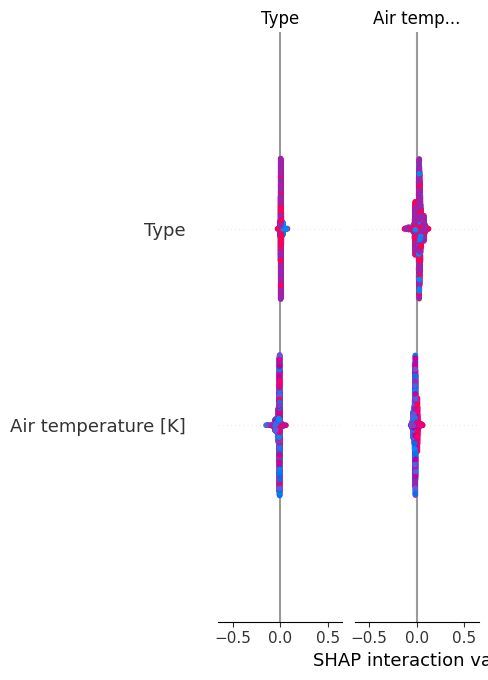


=== SMART DECISION ===
Healthy
Healthy
Healthy
Healthy
Healthy


In [2]:
# =========================================================
# SMSE PROJECT (Anomaly Detection/Prediction)-PART 2
# =========================================================

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_absolute_error

from sklearn.ensemble import RandomForestClassifier, IsolationForest, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier, XGBRegressor

from imblearn.over_sampling import SMOTE

from deap import base, creator, tools, algorithms

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, Input

import shap

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv("C:/Users/vv075/Downloads/SMSE-Project/MATLAB/ai4i2020.csv.csv")
df.drop(["UDI","Product ID"], axis=1, inplace=True)

# =========================================================
# 2. FEATURE ENGINEERING
# =========================================================
df["Temp Diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["Power"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"]

df["Failure Type"] = df[["TWF","HDF","PWF","OSF","RNF"]].idxmax(axis=1)
df["RUL"] = df["Tool wear [min]"].max() - df["Tool wear [min]"]

# Encoding
le = LabelEncoder()
df["Type"] = le.fit_transform(df["Type"])
df["Failure Type"] = le.fit_transform(df["Failure Type"])

# =========================================================
# 3. TARGETS
# =========================================================
X = df.drop(["Machine failure","Failure Type","RUL"], axis=1)
y = df["Machine failure"]
y_multi = df["Failure Type"]
y_rul = df["RUL"]

# =========================================================
# 4. SPLIT + SCALE + SMOTE
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# =========================================================
# 5. GA FEATURE SELECTION 
# =========================================================
from deap import creator

if "FitnessMax" in creator.__dict__:
    del creator.FitnessMax
if "Individual" in creator.__dict__:
    del creator.Individual

n_features = X_train.shape[1]

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=n_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_features(ind):
    selected = [i for i in range(len(ind)) if ind[i]==1]
    if len(selected)==0:
        return (0,)
    model = RandomForestClassifier()
    model.fit(X_train[:,selected], y_train)
    pred = model.predict(X_test[:,selected])
    return (accuracy_score(y_test, pred),)

toolbox.register("evaluate", eval_features)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=20)
algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=5, verbose=False)

best = tools.selBest(pop,1)[0]
selected_features = [i for i in range(len(best)) if best[i]==1]

# IMPORTANT FIX
selected_features = selected_features[:X_train.shape[1]]

X_train = X_train[:,selected_features]
X_test = X_test[:,selected_features]

feature_names = X.columns[selected_features]

# =========================================================
# 6. HYPERPARAMETER TUNING
# =========================================================
grid = GridSearchCV(RandomForestClassifier(), {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}, cv=3)

grid.fit(X_train, y_train)
best_rf = grid.best_estimator_

# =========================================================
# 7. ENSEMBLE MODEL
# =========================================================
ensemble = VotingClassifier(estimators=[
    ('rf', best_rf),
    ('xgb', XGBClassifier(eval_metric='logloss')),
    ('svm', SVC(probability=True))
], voting='soft')

ensemble.fit(X_train, y_train)

# =========================================================
# 8. EVALUATION
# =========================================================
probs = ensemble.predict_proba(X_test)[:,1]
preds = (probs > 0.4).astype(int)

print("\n=== FINAL MODEL ===")
print("Accuracy:", accuracy_score(y_test, preds))
print("F1:", f1_score(y_test, preds))
print("AUC:", roc_auc_score(y_test, probs))

# =========================================================
# 9. FAILURE TYPE
# =========================================================
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X, y_multi, test_size=0.2, random_state=42)

scaler2 = MinMaxScaler()
X_tr2 = scaler2.fit_transform(X_tr2)
X_te2 = scaler2.transform(X_te2)

model_multi = XGBClassifier()
model_multi.fit(X_tr2, y_tr2)

print("\nFailure Type Accuracy:", accuracy_score(y_te2, model_multi.predict(X_te2)))

# =========================================================
# 10. RUL
# =========================================================
X_tr3, X_te3, y_tr3, y_te3 = train_test_split(X, y_rul, test_size=0.2, random_state=42)

scaler3 = MinMaxScaler()
X_tr3 = scaler3.fit_transform(X_tr3)
X_te3 = scaler3.transform(X_te3)

model_rul = XGBRegressor()
model_rul.fit(X_tr3, y_tr3)

print("\nRUL MAE:", mean_absolute_error(y_te3, model_rul.predict(X_te3)))

# =========================================================
# 11. ANOMALY DETECTION
# =========================================================
iso = IsolationForest(contamination=0.05)
iso.fit(X_train)
iso_pred = iso.predict(X_test)

# =========================================================
# 12. AUTOENCODER
# =========================================================
X_normal = X_train[y_train==0]

input_dim = X_normal.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)
decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_normal, X_normal, epochs=10, batch_size=32, verbose=0)

recon = autoencoder.predict(X_test)
mse = np.mean((X_test - recon)**2, axis=1)

threshold = np.percentile(mse,95)
ae_pred = (mse > threshold).astype(int)

final_anomaly = np.logical_or(ae_pred, iso_pred==-1)
print("\nAnomalies:", np.sum(final_anomaly))

# =========================================================
# 13. ANN
# =========================================================
ann = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann.compile(optimizer='adam', loss='binary_crossentropy')
ann.fit(X_train, y_train, epochs=5, verbose=0)

# =========================================================
# 14. LSTM
# =========================================================
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1],1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1],1))

lstm = Sequential([
    Input(shape=(X_train.shape[1],1)),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

lstm.compile(optimizer='adam', loss='binary_crossentropy')
lstm.fit(X_train_lstm, y_train, epochs=5, verbose=0)

# =========================================================
# 15. SHAP 
# =========================================================
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values, X_test_df)

# =========================================================
# 16. SMART DECISION
# =========================================================
print("\n=== SMART DECISION ===")
for i in range(5):
    p = probs[i]
    if p > 0.8:
        print("Immediate Maintenance")
    elif p > 0.5:
        print("Schedule Maintenance")
    else:
        print("Healthy")

In [3]:
# =========================================================
# ALL MODELS COMPARISON 
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier

models = {
    "Logistic": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree (Gini)": DecisionTreeClassifier(),
    "Decision Tree (Entropy)": DecisionTreeClassifier(criterion="entropy"),
    "RandomForest": RandomForestClassifier(),
    "GradientBoost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

print("\n===== ALL MODELS PERFORMANCE =====")

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("F1:", f1)
    print("AUC:", auc)

    results.append([name, acc, f1, auc])

# Convert to DataFrame
df_results = pd.DataFrame(results, columns=["Model","Accuracy","F1","AUC"])
print("\n=== MODEL COMPARISON TABLE ===")
print(df_results)


===== ALL MODELS PERFORMANCE =====

Logistic
Accuracy: 0.999
F1: 0.9833333333333333
AUC: 0.982270732758985

KNN
Accuracy: 0.995
F1: 0.921875
AUC: 0.9833360106189601

SVM
Accuracy: 0.999
F1: 0.9833333333333333
AUC: 0.9822030960694629

Decision Tree (Gini)
Accuracy: 0.99
F1: 0.855072463768116
AUC: 0.978964989558586

Decision Tree (Entropy)
Accuracy: 0.991
F1: 0.8676470588235294
AUC: 0.9794807193161932

RandomForest
Accuracy: 0.999
F1: 0.9833333333333333
AUC: 0.977722165388615

GradientBoost
Accuracy: 0.999
F1: 0.9833333333333333
AUC: 0.9903279533983209

AdaBoost
Accuracy: 0.999
F1: 0.9833333333333333
AUC: 0.9815859112775724

Bagging
Accuracy: 0.9985
F1: 0.9752066115702479
AUC: 0.9827695533442116

XGBoost
Accuracy: 0.998
F1: 0.9672131147540983
AUC: 0.9895839498135763

=== MODEL COMPARISON TABLE ===
                     Model  Accuracy        F1       AUC
0                 Logistic    0.9990  0.983333  0.982271
1                      KNN    0.9950  0.921875  0.983336
2                    

In [16]:
print("Selected features:", len(selected_features))
print("X_train shape:", X_train.shape)

Selected features: 10
X_train shape: (15444, 10)


In [4]:
# save_model.py

import pandas as pd
import joblib

from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier

# Load Dataset
df = pd.read_csv("C:/Users/vv075/Downloads/SMSE-Project/MATLAB/ai4i2020.csv.csv")

# Drop unnecessary columns
df = df.drop(["UDI", "Product ID"], axis=1)

# Feature Engineering
df["Temp Diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["Power"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"]

# Encode categorical column
df["Type"] = df["Type"].astype("category").cat.codes

# Features and Target
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

# Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# XGBoost Model
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Train Model
model.fit(X_scaled, y)

# Save Model
joblib.dump(model, "model.pkl")

# Save Scaler
joblib.dump(scaler, "scaler.pkl")

print("XGBoost Model and Scaler Saved Successfully")

XGBoost Model and Scaler Saved Successfully
